# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [20]:
import pandas as pd
import matplotlib.pyplot as mlib
import seaborn as sb

df = pd.read_csv('loan_data.csv')

df.head(25)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1
5,22,male,Bachelor,70130.700025,6,MORTGAGE,9008.104188,VENTURE,12.575501,0.128447,22,770.974257,No,0
6,41,female,Associate,86965.993882,11,OWN,23398.537788,EDUCATION,11.770607,0.269054,19,596.305523,No,1
7,72,female,Associate,60412.931964,6,MORTGAGE,24495.392501,PERSONAL,9.146556,0.405466,19,734.020668,No,0
8,21,male,Bachelor,77241.160427,25,RENT,17674.382881,DEBTCONSOLIDATION,14.211276,0.228821,22,653.042056,No,0
9,49,male,Doctorate,57373.429325,4,OWN,14848.496412,PERSONAL,12.188035,0.258804,26,738.978230,No,1


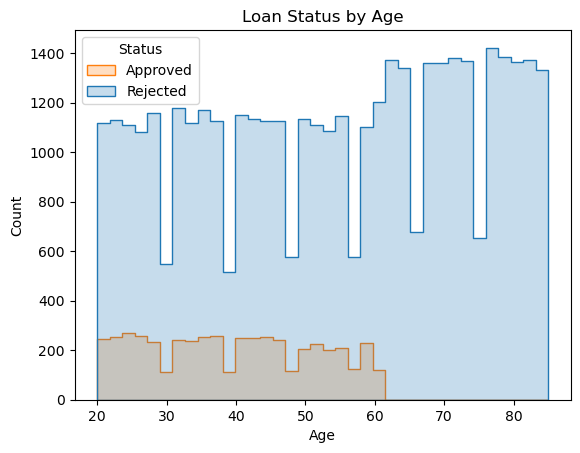

In [ ]:
#age
sb.histplot(x='person_age', data=df, hue="loan_status", element="step")

mlib.title('Loan Status by Age')
mlib.xlabel('Age')

mlib.legend(labels=['Approved', 'Rejected'],title='Status') # for some reason the labels are backwards

Text(0.5, 0, 'Approval Status')

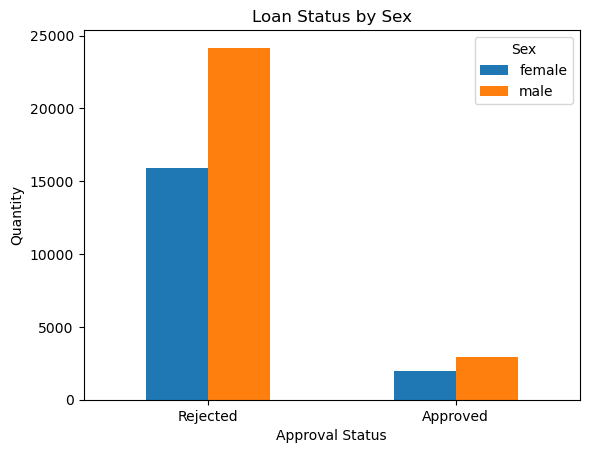

In [ ]:
#sex
sex_ct = pd.crosstab(df['loan_status'], df['person_gender'])
sex_ct.plot(kind='bar', stacked=False, title='Loan Status by Sex', ylabel='Count')
mlib.xticks([0, 1], ['Rejected', 'Approved'], rotation = 0)
mlib.legend(title='Sex')
mlib.xlabel('Approval Status')

Text(0.5, 0, 'Approval Status')

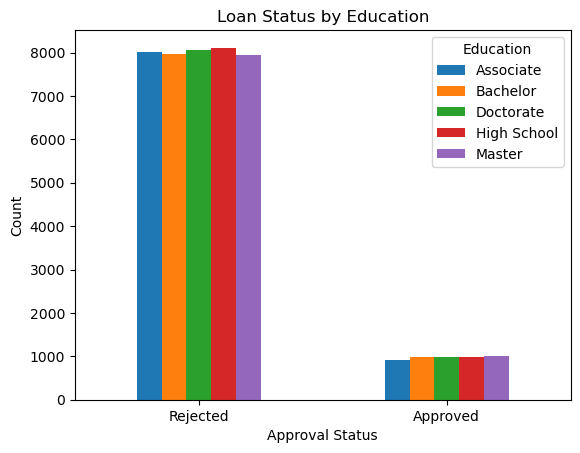

In [ ]:
#education
edu_ct = pd.crosstab(df['loan_status'], df['person_education'])
edu_ct.plot(kind='bar', stacked=False, title='Loan Status by Education', ylabel='Count')
mlib.xticks([0, 1], ['Rejected', 'Approved'], rotation = 0)
mlib.legend(title='Education')
mlib.xlabel('Approval Status')

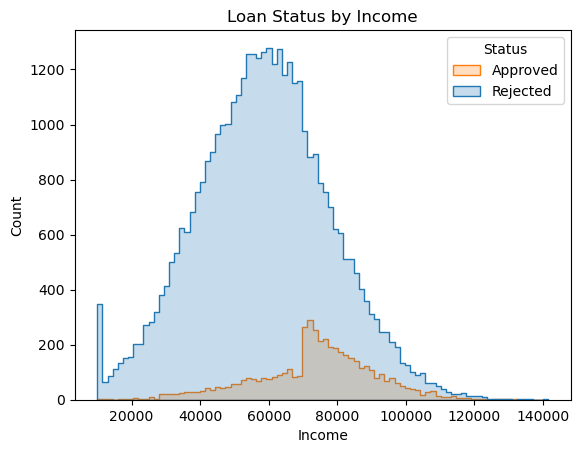

In [49]:
#income
sb.histplot(x='person_income', data=df, hue="loan_status", element="step")

mlib.title('Loan Status by Income')
mlib.xlabel('Income')

mlib.legend(labels=['Approved', 'Rejected'],title='Status')

Text(0.5, 0, 'Approval Status')

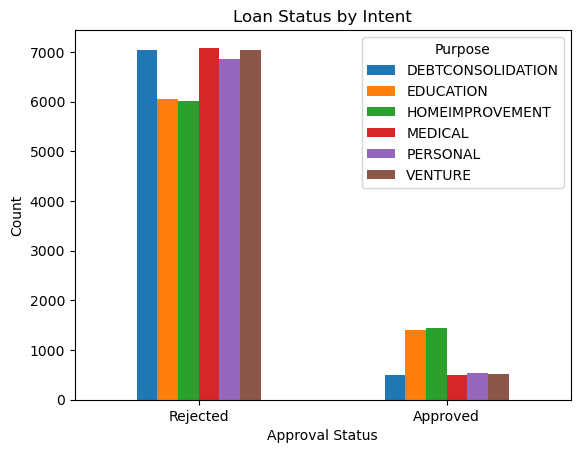

In [50]:
#purpose
edu_ct = pd.crosstab(df['loan_status'], df['loan_intent'])
edu_ct.plot(kind='bar', stacked=False, title='Loan Status by Intent', ylabel='Count')
mlib.xticks([0, 1], ['Rejected', 'Approved'], rotation = 0)
mlib.legend(title='Purpose')
mlib.xlabel('Approval Status')

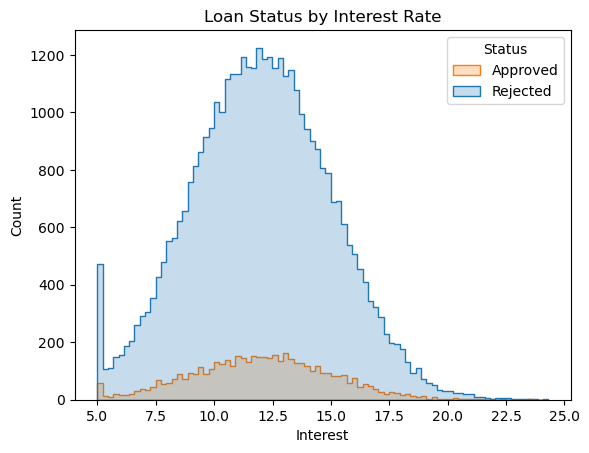

In [51]:
#interest rate
sb.histplot(x='loan_int_rate', data=df, hue="loan_status", element="step")

mlib.title('Loan Status by Interest Rate')
mlib.xlabel('Interest')

mlib.legend(labels=['Approved', 'Rejected'],title='Status')

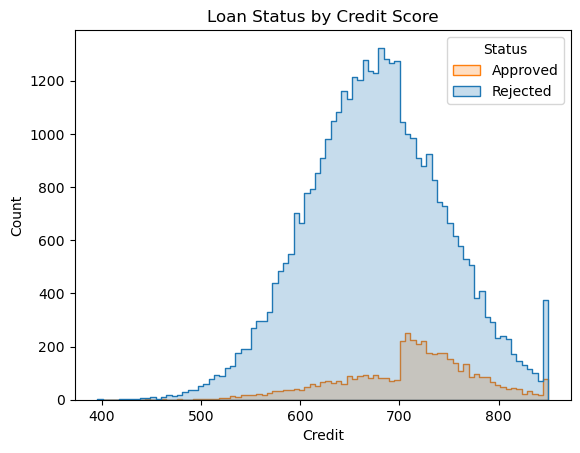

In [52]:
#credit score
sb.histplot(x='credit_score', data=df, hue="loan_status", element="step")

mlib.title('Loan Status by Credit Score')
mlib.xlabel('Credit')

mlib.legend(labels=['Approved', 'Rejected'],title='Status')

## Conclusions

* Age: There isn't any significant correlation with age until 60-62, in which there appear to be no loan approvals at all. It makes sense to approve fewer, given potential mental decline in old age, but the complete lack of any loans should be cause for concern. It is also interesting that there are major gaps in applications for certain ages, though that isn't a primary concern.

* Sex: I don't believe there is significant correleation with sex. There is an increase in male approvals, but there is a seemingly proportional increase to male rejections. This just suggests that men apply for more loans.  

* Education: There appears to be no correlation with education. Each category has nearly equal rates.  

* Income: There is a slight correlation between approvals and income. The curve of rejections is centered slightly further left, suggesting lower income results in rejections more often. There is also a slight jump in approvals at about 70,000 and above.  

* Loan Intent: There is certainly correlation with intent. Loans used for home improvement and education are approved far more often than for other purposes.

* Interest: There doesn't seem to be any correlation with interest rate. Their curves are in the same locatiion with a similar shape (though flatter for approvals of course). This really surprised me. I'd expect a bank to prioritize higher rates for more income.

* Credit Score: There is definitely correlation with credit score. Around a score of 700, the approval count increases significantly, and the rejection count increases. There continues to be the same respective changes with higher scores.


Correlation: Age, Income, Intent, Credit score  
No correlation: Sex, Education, Interest rate

I see no cause for legal concern so long as age biases are accounted for. There should at least be some approvals for older customers. I would also investigate loan intent, as that could potentially be seen as discriminating. Otherwise, biases seem purely financial. I would bring attention to some significant spikes at both the low and high end of several categories. In all cases but income, however, the approval seems to spike at least somewhat proportionately with rejections, and likely isn't a major cause for concern.